In [1]:
import netCDF4 as nc
import matplotlib.pyplot as plt
from matplotlib.colors import from_levels_and_colors
import numpy as np
from matplotlib import animation
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as cols
import matplotlib as mpl
from mpl_toolkits.basemap import Basemap
from matplotlib import ticker, cm
import seaborn as sns

In [2]:
sigma1yes = np.load('/media/dell/Elements/new/seperatesigma1copy/sigma1all0yeswhole.npy')
sigma1no = np.load('/media/dell/Elements/new/seperatesigma1copy/sigma1all0nowhole.npy')

sigma1diff = sigma1yes - sigma1no

In [3]:
data222=nc.Dataset('/home/dell/iHESPdata/iHESPocn/B.E.13.B1850C5.ne120_t12.sehires38.003.sunway_02.pop.h.0295-12.nc')
plotvarKMT = data222.variables['KMT'][:,:]
data=nc.Dataset('/media/dell/Elements/new/SDENFsigma1/B.E.13.B1850C5.ne120_t12.sehires38.003.sunway_02.pop.h.0375-06.SDEN_F.nc')
lontu = data.variables['TLONG'][:,:]
lattu = data.variables['TLAT'][:,:]
lont = data.variables['TLONG'][:,:]
latt = data.variables['TLAT'][:,:]
data2=nc.Dataset('/home/dell/iHESPdata/iHESPocn/B.E.13.B1850C5.ne120_t12.sehires38.003.sunway_02.pop.h.0295-12.nc')
plotvar2 = data2.variables['z_w_bot'][:]

In [4]:
lont2 = lont[249,480:1080]
latt2 = latt[249,480:1080]

In [5]:
lontu[lontu ==-1] = np.nan
lattu[lattu ==-1] = np.nan

/home/dell/anaconda3/envs/Xiliangdiao/lib/python3.6/site-packages/ipykernel_launcher.py:32: UserWarning: The following kwargs were not used by contour: 'spacing'
/home/dell/anaconda3/envs/Xiliangdiao/lib/python3.6/site-packages/ipykernel_launcher.py:71: UserWarning: The following kwargs were not used by contour: 'spacing'
/home/dell/anaconda3/envs/Xiliangdiao/lib/python3.6/site-packages/ipykernel_launcher.py:118: UserWarning: The following kwargs were not used by contour: 'spacing'


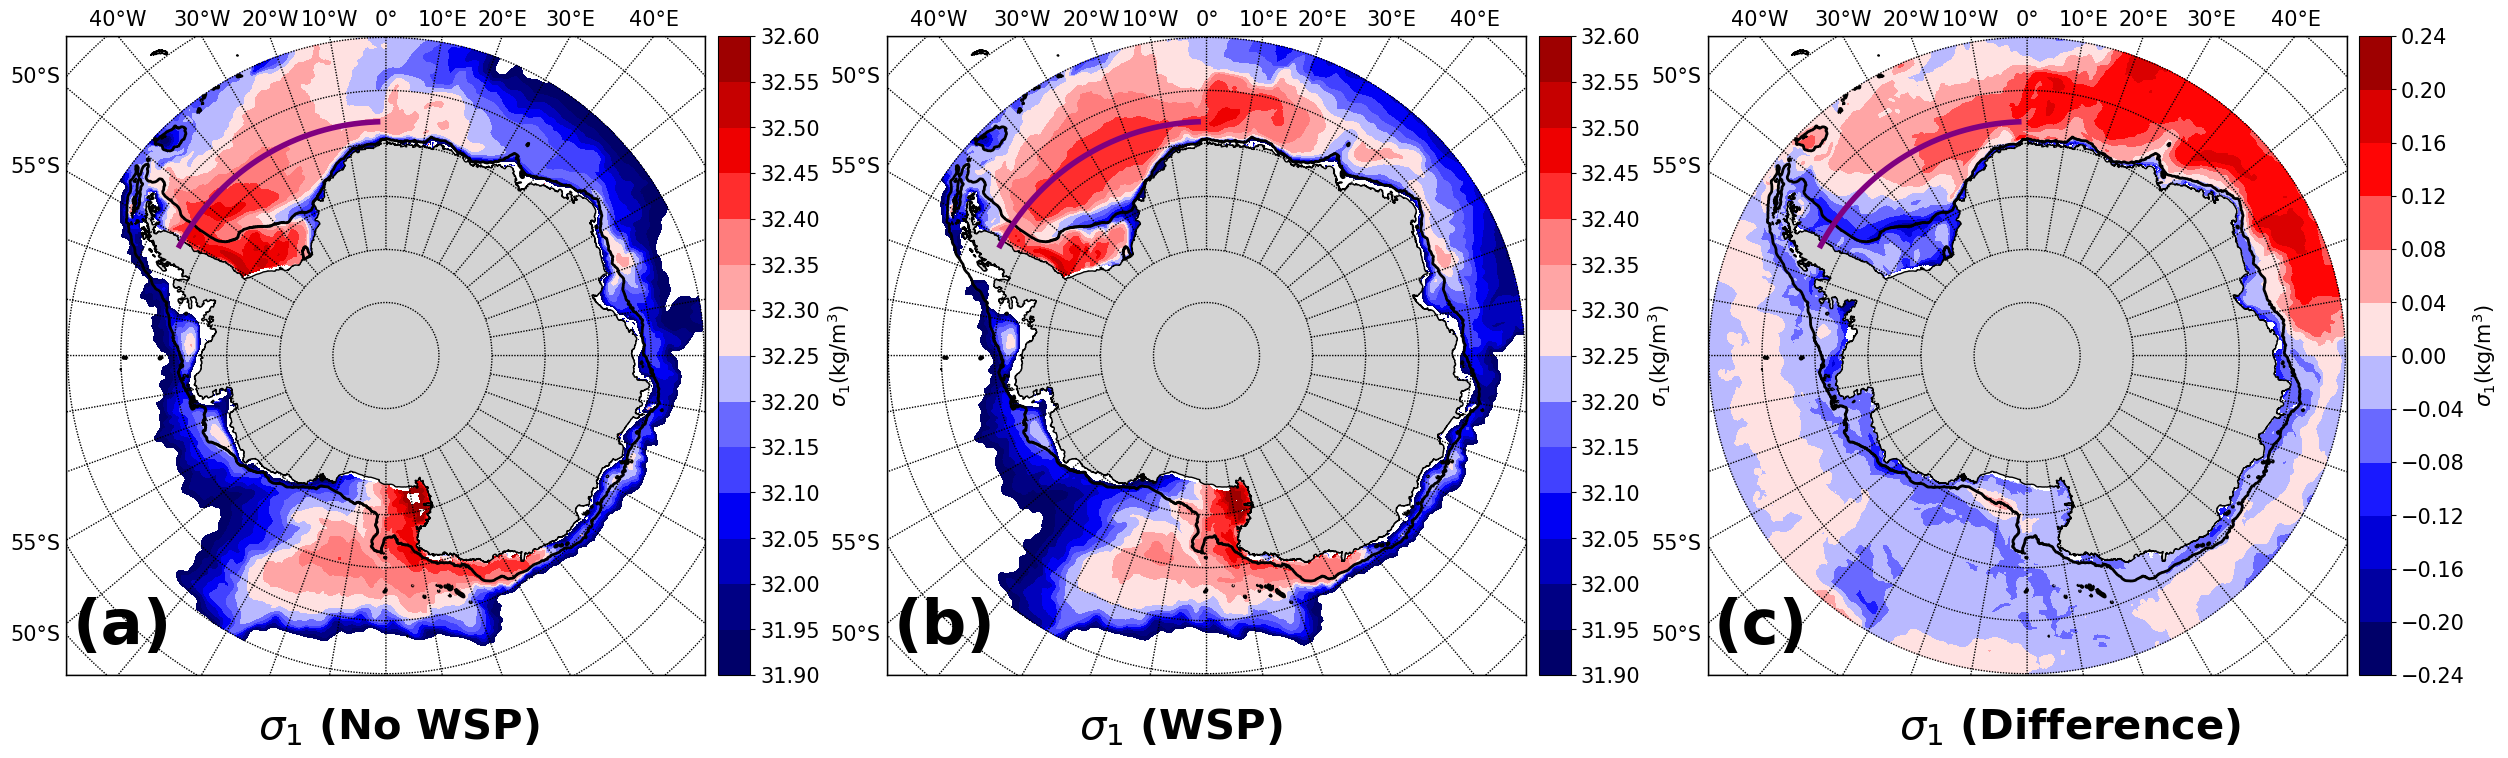

In [6]:
nice_cmap=plt.get_cmap('seismic')
lev_cmap = nice_cmap([10,20,30,40,50,60,70,80,90,100,110,120,135,140,150,160,170,180,190,\
                      200,210,220,230,240])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [31.9,31.95,32,32.05,32.1,32.15,32.2,32.25,32.3,32.35,32.4,32.45,32.5,32.55,32.6]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#********************************************************************
nice_levels2 = [3000]

fig = plt.figure(figsize=(30,20), dpi=100)

ax0 = plt.subplot(1, 3, 1)
#plt.figure(figsize=(25,20))
#my_font = {'fontname':'Cambria', 'size':'15'}
my_font = { 'size':'15'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
                     width = 6700000,height = 6700000,resolution ='h') 
#############################################
##width = 2500000,height = 1500000
##lat_0 = -65, lon_0 = 0
#############################################
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(lontu,lattu)

CP = map.contourf(x[:428,:],y[:428,:],sigma1no[:428,:],levels = nice_levels,cmap = new_cmap,norm =norm,spacing = 'uniform')#,extend='both')
#CP.cmap.set_over('firebrick')
#CP.cmap.set_under('darkblue')
x2,y2=map(lont2,latt2)
map.plot(x2,y2,'purple',linewidth=4)
cbar =map.colorbar(CP,extendfrac='auto',ticks= nice_levels)
#cbar.minorticks_on()
cbar.ax.tick_params(labelsize=15) 
#cbar.set_label('(kg/m$^3$)', **my_font)
cbar.set_label('$\sigma$$_1$(kg/m$^3$)', **my_font)
xq,yq=map(lontu,lattu)
CS = map.contour(xq[:428,:],yq[:428,:],plotvarKMT[:428,:],[40],colors= 'black',linestyles = 'solid',linewidths=2)

xq,yq=map(lontu,lattu)
#CS = map.contour(x[:428,:],y[:428,:],fin2[:428,:],[37.35],colors= 'black',linestyles = 'solid',linewidths=2) 
ax0.text(0.01, 0.05, '(a)', transform=ax0.transAxes,size=45, weight='bold')
ax0.text(0.3, -0.1, '$\sigma$$_1$ (No WSP)', transform=ax0.transAxes,size=30, weight='bold')
#ax0.text(0.05, 0.01, '(a) No', transform=ax0.transAxes,size=30, weight='bold')

ax0 = plt.subplot(1, 3, 2)
#plt.figure(figsize=(25,20))
#my_font = {'fontname':'Cambria', 'size':'15'}
my_font = { 'size':'15'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
                     width = 6700000,height = 6700000,resolution ='h') 
#############################################
##width = 2500000,height = 1500000
##lat_0 = -65, lon_0 = 0
#############################################
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(lontu,lattu)

CP = map.contourf(x[:428,:],y[:428,:],sigma1yes[:428,:],levels = nice_levels,cmap = new_cmap,norm =norm,spacing = 'uniform')#,extend='both')
#CP.cmap.set_over('firebrick')
#CP.cmap.set_under('darkblue')

cbar =map.colorbar(CP,extendfrac='auto',ticks= nice_levels)
#cbar.minorticks_on()
cbar.ax.tick_params(labelsize=15) 
#cbar.set_label('(kg/m$^3$)', **my_font)
cbar.set_label('$\sigma$$_1$(kg/m$^3$)', **my_font)
xq,yq=map(lontu,lattu)
CS = map.contour(xq[:428,:],yq[:428,:],plotvarKMT[:428,:],[40],colors= 'black',linestyles = 'solid',linewidths=2)

xq,yq=map(lontu,lattu)
#CS = map.contour(x[:428,:],y[:428,:],fin2[:428,:],[37.35],colors= 'black',linestyles = 'solid',linewidths=2) 
x2,y2=map(lont2,latt2)
map.plot(x2,y2,'purple',linewidth=4)
#ax0.text(0.05, 0.01, '(b) WSP', transform=ax0.transAxes,size=30, weight='bold')
ax0.text(0.01, 0.05, '(b)', transform=ax0.transAxes,size=45, weight='bold')
ax0.text(0.3, -0.1, '$\sigma$$_1$ (WSP)', transform=ax0.transAxes,size=30, weight='bold')

nice_cmap=plt.get_cmap('seismic')
lev_cmap = nice_cmap([10,20,30,40,50,60,70,80,90,100,110,120,135,140,150,160,170,180,190,\
                      200,210,220,230,240])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [-0.24,-0.2,-0.16,-0.12,-0.08,-0.04,0,0.04,0.08,0.12,0.16,0.2,0.24]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#********************************************************************
ax0 = plt.subplot(1, 3, 3)
#plt.figure(figsize=(25,20))
#my_font = {'fontname':'Cambria', 'size':'15'}
my_font = { 'size':'15'}
# set the mapping range
map = Basemap(projection='aeqd', lat_0 = -90, lon_0 = 0,area_thresh = 100,\
                     width = 6700000,height = 6700000,resolution ='h') 
#############################################
##width = 2500000,height = 1500000
##lat_0 = -65, lon_0 = 0
#############################################
map.drawcoastlines()
map.fillcontinents(color = 'lightgrey')
map.drawmapboundary(color='black')
 
map.drawparallels(np.arange(-90,91,5),labels=[1,0,0,0],**my_font)
map.drawmeridians(np.arange(-180,180,10),labels=[0,0,1,0],**my_font)

x,y=map(lontu,lattu)

CP = map.contourf(x[:428,:],y[:428,:],sigma1diff[:428,:],levels = nice_levels,cmap = new_cmap,norm =norm,spacing = 'uniform')#,extend='both')
#CP.cmap.set_over('firebrick')
#CP.cmap.set_under('darkblue')

cbar =map.colorbar(CP,extendfrac='auto',ticks= nice_levels)
#cbar.minorticks_on()
cbar.ax.tick_params(labelsize=15) 
#cbar.set_label('(kg/m$^3$)', **my_font)
cbar.set_label('$\sigma$$_1$(kg/m$^3$)', **my_font)
xq,yq=map(lontu,lattu)
CS = map.contour(xq[:428,:],yq[:428,:],plotvarKMT[:428,:],[40],colors= 'black',linestyles = 'solid',linewidths=2)
x2,y2=map(lont2,latt2)
map.plot(x2,y2,'purple',linewidth=4)
xq,yq=map(lontu,lattu)
#CS = map.contour(x[:428,:],y[:428,:],fin2[:428,:],[37.35],colors= 'black',linestyles = 'solid',linewidths=2) 

ax0.text(0.01, 0.05, '(c)', transform=ax0.transAxes,size=45, weight='bold')
ax0.text(0.3, -0.1, '$\sigma$$_1$ (Difference)', transform=ax0.transAxes,size=30, weight='bold')
plt.savefig("FigSS3.png",bbox_inches='tight')
